Running simulations...


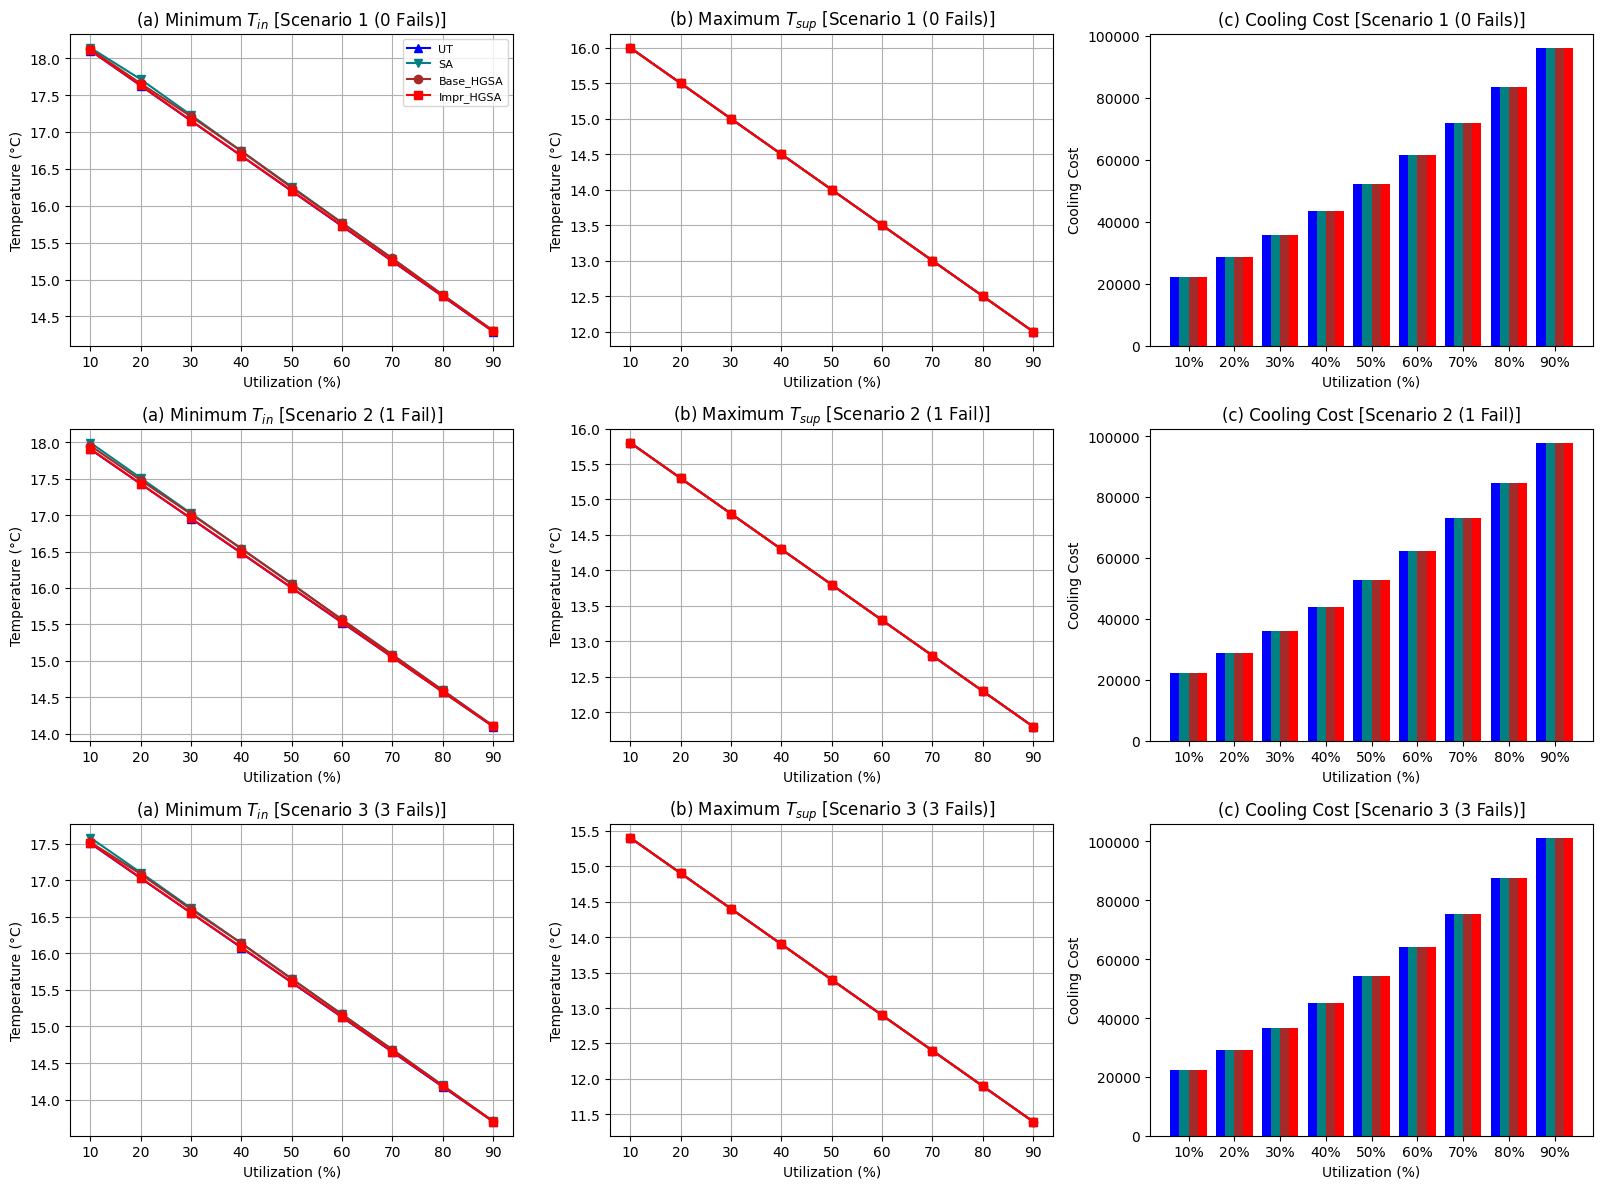

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import random
import math

# ------------------------------
# 1. Data Center Setup
# ------------------------------
NUM_NODES = 50       
MAX_CAPACITY = 100   
P_IDLE = 50.0        
P_ACTIVE = 200.0     

# Synthetic Heat Cross-Interference Matrix
D_MATRIX = np.zeros((NUM_NODES, NUM_NODES))
for i in range(NUM_NODES):
    for j in range(NUM_NODES):
        if i == j:
            D_MATRIX[i][j] = 0.5  
        else:
            D_MATRIX[i][j] = 0.1 / (abs(i - j) + 1)

def calc_cop(T_sup):
    return 0.0068 * (T_sup**2) + 0.0008 * T_sup + 0.4580


def calculate_metrics(solution, failed_nodes, utilization):
    """Calculates performance metrics."""
    P_node = np.zeros(NUM_NODES)

    for i in range(NUM_NODES):
        if i not in failed_nodes:
            if solution[i] > 0:
                P_node[i] = P_IDLE + (solution[i] / MAX_CAPACITY) * (P_ACTIVE - P_IDLE)
            else:
                P_node[i] = P_IDLE
        else:
            P_node[i] = 0.0

    P_IT = np.sum(P_node)

    # Supply temperature drops as utilization increases
    base_T_sup = 16.5 - (utilization / 100.0) * 5.0
    T_sup = base_T_sup - (len(failed_nodes) * 0.2)

    heat_rise = np.dot(D_MATRIX, P_node) * 0.0015
    max_T_in = T_sup + np.max(heat_rise) + 2.0

    cop = calc_cop(T_sup)
    P_AC = (P_IT / cop) * 15.0

    return max_T_in, T_sup, P_AC


def preserve_constraints(solution, C_total, failed_nodes):
    for f in failed_nodes:
        solution[f] = 0

    diff = C_total - sum(solution)
    active_nodes = [i for i in range(NUM_NODES) if i not in failed_nodes]

    while diff != 0:
        idx = random.choice(active_nodes)
        if diff > 0 and solution[idx] < MAX_CAPACITY:
            solution[idx] += 1
            diff -= 1
        elif diff < 0 and solution[idx] > 0:
            solution[idx] -= 1
            diff += 1
    return solution


# ------------------------------
# 2. Algorithms
# ------------------------------

def run_ut(C_total, failed_nodes, utilization):
    active_count = NUM_NODES - len(failed_nodes)
    base_load = C_total // active_count
    rem = C_total % active_count

    sol = [0] * NUM_NODES
    active_idx = 0
    for i in range(NUM_NODES):
        if i not in failed_nodes:
            sol[i] = base_load + (1 if active_idx < rem else 0)
            active_idx += 1

    return calculate_metrics(sol, failed_nodes, utilization)


def run_sa(C_total, failed_nodes, utilization):
    T = 1000.0
    T_end = 1.0
    q = 0.85
    L = 10

    active_nodes = [i for i in range(NUM_NODES) if i not in failed_nodes]

    current_sol = preserve_constraints([0]*NUM_NODES, C_total, failed_nodes)
    best_temp, _, _ = calculate_metrics(current_sol, failed_nodes, utilization)

    while T > T_end:
        for _ in range(L):
            new_sol = copy.deepcopy(current_sol)

            src, dst = random.choice(active_nodes), random.choice(active_nodes)
            if src != dst and new_sol[src] > 0 and new_sol[dst] < MAX_CAPACITY:
                transfer = random.randint(1, min(new_sol[src], MAX_CAPACITY - new_sol[dst]))
                new_sol[src] -= transfer
                new_sol[dst] += transfer

            new_temp, _, _ = calculate_metrics(new_sol, failed_nodes, utilization)
            delta = new_temp - best_temp

            if delta < 0 or random.random() < math.exp(-delta / T):
                current_sol = copy.deepcopy(new_sol)
                if new_temp < best_temp:
                    best_temp = new_temp

        T *= q

    return calculate_metrics(current_sol, failed_nodes, utilization)


def run_hgsa(C_total, failed_nodes, utilization, is_improved=False):
    T = 1000.0
    T_end = 1.0
    q = 0.85
    L = 10
    Pm = 0.1

    active_nodes = [i for i in range(NUM_NODES) if i not in failed_nodes]

    current_sol = preserve_constraints([0]*NUM_NODES, C_total, failed_nodes)
    best_sol = copy.deepcopy(current_sol)
    best_temp, _, _ = calculate_metrics(best_sol, failed_nodes, utilization)

    while T > T_end:
        for _ in range(L):
            new_sol = copy.deepcopy(current_sol)

            r1, r2 = random.choice(active_nodes), random.choice(active_nodes)
            new_sol[r1], new_sol[r2] = new_sol[r2], new_sol[r1]

            if random.random() < Pm:
                idx1 = random.choice(active_nodes)
                while new_sol[idx1] == 0:
                    idx1 = random.choice(active_nodes)

                idx2 = random.choice(active_nodes)
                while idx1 == idx2 or new_sol[idx2] == MAX_CAPACITY:
                    idx2 = random.choice(active_nodes)

                transfer = random.randint(1, min(new_sol[idx1], MAX_CAPACITY - new_sol[idx2]))
                new_sol[idx1] -= transfer
                new_sol[idx2] += transfer

            new_temp, _, _ = calculate_metrics(new_sol, failed_nodes, utilization)
            current_temp, _, _ = calculate_metrics(current_sol, failed_nodes, utilization)

            delta = new_temp - current_temp

            if delta < 0:
                current_sol = copy.deepcopy(new_sol)
                if new_temp < best_temp:
                    best_sol = copy.deepcopy(new_sol)
                    best_temp = new_temp
            else:
                if random.random() < math.exp(-delta / T):
                    current_sol = copy.deepcopy(new_sol)

        if is_improved:
            current_sol = copy.deepcopy(best_sol)

        T *= q

    return calculate_metrics(current_sol, failed_nodes, utilization)


# ------------------------------
# 3. Execute Scenarios
# ------------------------------

utilizations = [10,20,30,40,50,60,70,80,90]

scenarios = {
    'Scenario 1 (0 Fails)': [],
    'Scenario 2 (1 Fail)': [10],
    'Scenario 3 (3 Fails)': [10,25,40]
}

results = {}

print("Running simulations...")

for s_name, failed_nodes in scenarios.items():

    results[s_name] = {
        'UT': {'T_in':[], 'T_sup':[], 'P_AC':[]},
        'SA': {'T_in':[], 'T_sup':[], 'P_AC':[]},
        'Base_HGSA': {'T_in':[], 'T_sup':[], 'P_AC':[]},
        'Impr_HGSA': {'T_in':[], 'T_sup':[], 'P_AC':[]}
    }

    for u in utilizations:
        c_total = int((u/100.0)*(NUM_NODES*MAX_CAPACITY))

        algorithms = {
            'UT': lambda: run_ut(c_total, failed_nodes, u),
            'SA': lambda: run_sa(c_total, failed_nodes, u),
            'Base_HGSA': lambda: run_hgsa(c_total, failed_nodes, u, False),
            'Impr_HGSA': lambda: run_hgsa(c_total, failed_nodes, u, True)
        }

        for name, func in algorithms.items():
            t_in, t_sup, p_ac = func()
            results[s_name][name]['T_in'].append(t_in)
            results[s_name][name]['T_sup'].append(t_sup)
            results[s_name][name]['P_AC'].append(p_ac)


# ------------------------------
# 4. Plot 3x3 Grid
# ------------------------------

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

colors = {'UT':'blue','SA':'teal','Base_HGSA':'brown','Impr_HGSA':'red'}
markers = {'UT':'^','SA':'v','Base_HGSA':'o','Impr_HGSA':'s'}

for row, (s_name, s_data) in enumerate(results.items()):

    # (a) T_in
    ax1 = axes[row,0]
    for alg in colors:
        ax1.plot(utilizations, s_data[alg]['T_in'],
                 marker=markers[alg], color=colors[alg], label=alg)
    ax1.set_title(f'(a) Minimum $T_{{in}}$ [{s_name}]')
    ax1.set_xlabel('Utilization (%)')
    ax1.set_ylabel('Temperature (°C)')
    ax1.grid(True)
    if row == 0:
        ax1.legend(fontsize=8)

    # (b) T_sup
    ax2 = axes[row,1]
    for alg in colors:
        ax2.plot(utilizations, s_data[alg]['T_sup'],
                 marker=markers[alg], color=colors[alg], label=alg)
    ax2.set_title(f'(b) Maximum $T_{{sup}}$ [{s_name}]')
    ax2.set_xlabel('Utilization (%)')
    ax2.set_ylabel('Temperature (°C)')
    ax2.grid(True)

    # (c) Cooling Cost
    ax3 = axes[row,2]
    x = np.arange(len(utilizations))
    width = 0.2

    for i, alg in enumerate(colors):
        ax3.bar(x + (i-1.5)*width,
                s_data[alg]['P_AC'],
                width,
                color=colors[alg],
                label=alg)

    ax3.set_xticks(x)
    ax3.set_xticklabels([f"{u}%" for u in utilizations])
    ax3.set_title(f'(c) Cooling Cost [{s_name}]')
    ax3.set_xlabel('Utilization (%)')
    ax3.set_ylabel('Cooling Cost')

plt.tight_layout()
plt.show()